# Fosback's Negative Volume Index — a quantitative teardown 🔬
### The 74-year annual replication + Wilson intervals · a 20,000-draw label-shuffle placebo · the overlapping-return trap (naive vs Newey-West *t*) · a costed SPY timer with its own circular-shift placebo · a sample-half split · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![96%25 bull odds%3F: Busted](https://img.shields.io/badge/96%25_bull_odds%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — Fosback's NVI above its 255-session EMA carries 96% reliability for a bull market — is a rare case of technical-analysis folklore with a *precise, falsifiable* quoted number and a *named* mechanism (informed trading on low-volume days). Both make it worth measuring honestly instead of dismissing or repeating on faith.

> ⚠️ **Data note.** ^GSPC daily OHLCV (1950→2026, price-only index) + SPY total-return OHLCV (1993→2026), yfinance, cached. NVI is built on each series' **own** reported volume — a named proxy for the NYSE composite tape Fosback used in 1976. No survivorship (index + single ETF, no cross-sectional panel). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `d65c4c93a643` / `2f5662f8e29a`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from negative_volume_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    GSPC, SPY = data.load_real()
    N_GSPC = st.nvi(GSPC["Close"], GSPC["Volume"])
    E_GSPC = st.nvi_ema(N_GSPC, span=data.EMA_SPAN)
    REG_GSPC = st.regime(N_GSPC, E_GSPC)
    N_SPY = st.nvi(SPY["Close"], SPY["Volume"])
    E_SPY = st.nvi_ema(N_SPY, span=data.EMA_SPAN)
    REG_SPY = st.regime(N_SPY, E_SPY)
    POS_SPY = REG_SPY.fillna(False).astype(float)
else:
    GSPC = SPY = N_GSPC = E_GSPC = REG_GSPC = N_SPY = E_SPY = REG_SPY = POS_SPY = None
print("real cache present:", HAVE_REAL, "| ^GSPC sessions:",
      (0 if GSPC is None else len(GSPC)), "| SPY sessions:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'gspc_start': '1950-01-03', 'gspc_end': '2026-06-30', 'n_gspc': 19244, 'spy_start': '1993-01-29', 'spy_end': '2026-06-30', 'n_spy': 8411, 'ema_span': 255, 'fp_gspc': 'd65c4c93a643', 'fp_spy': '2f5662f8e29a', 'n_years': 74, 'lo_year': 1952, 'hi_year': 2025, 'p_on': 70.3, 'p_on_n': 37, 'p_on_ci': (54.2, 82.5), 'p_off': 75.7, 'p_off_n': 37, 'p_off_ci': (59.9, 86.6), 'p_all': 73.0, 'p_all_ci': (61.9, 81.8), 'gap_pp': -2.7, 'placebo_mean_pp': 0.0, 'placebo_sd_pp': 5.2, 'placebo_p': 0.79, 'placebo_draws': 20000, 'horizon': {21: (0.877, 0.611, 4.24, 1.18, 63.7, 59.4), 63: (2.49, 1.961, 4.98, 0.84, 69.8, 63.2), 252: (10.018, 8.435, 6.83, 0.6, 78.0, 70.5)}, 'time_on_pct': 93.2, 'sharpe_net0': 0.563, 'sharpe_net5': 0.56, 'sharpe_net10': 0.557, 'bh_sharpe': 0.647, 'cagr_net0': 8.76, 'cagr_net5': 8.69, 'cagr_net10': 8.62, 'bh_cagr': 10.83, 'spread0': -0.816, 'spread5': -0.84, 'spread10': -0.865, 't0': -2.38, 't5': -2.44, 't10': -2.5, 'n_switches': 41, 'switches_per_yr': 1.23, 'maxdd_net': -57.7, 'bh_maxdd': -55.2, 'perm_obs': -0.816, 'perm_mean': -0.312, 'perm_p': 0.985, 'perm_draws': 2000, 'h1_sharpe': 0.265, 'h1_bh_sharpe': 0.455, 'h1_spread': -1.681, 'h1_t': -2.45, 'h2_sharpe': 0.855, 'h2_bh_sharpe': 0.872, 'h2_spread': -0.329, 'h2_t': -0.81, 'syn_null_mean': -0.11, 'syn_null_sd': 0.94, 'syn_null_fire': 0, 'syn_seeds': 20, 'syn_planted_edge': 0.4, 'syn_on': 72.54, 'syn_off': 39.5, 'syn_welch': 28.64, 'syn_nw': 2.9}


real cache present: True | ^GSPC sessions: 19244 | SPY sessions: 8411


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | annual replication: P(up \| NVI>EMA) = **70.3%** (n=37) vs unconditional **73.0%** (n=74); gap **-2.7 pp**, placebo *p* = **0.790**. Daily cross-check: Newey-West *t* ≤ **+1.18** at every horizon |
| **Tradability** | `MIRAGE` | SPY long/flat timer active spread **-0.840 bps/day**, HAC **t = -2.44** (net, 5 bps); circular-shift placebo **p = 0.985** |
| **96% bull odds?** | `BUSTED` | replication lands at 70.3%, *below* the 73.0% base rate |

> 💡 In plain words: the folklore's mechanism is plausible on paper; on 74 years of tape it adds no information over the market's own drift, and the tradable version of the rule actively loses money.

## 1 · The claim, steelmanned

$$\text{NVI}_0 = 1000, \qquad \text{NVI}_t = \begin{cases} \text{NVI}_{t-1}(1+r_t) & \text{if } V_t < V_{t-1} \\ \text{NVI}_{t-1} & \text{otherwise} \end{cases}$$

Let $E_t$ be NVI's 255-session EMA and $D_t = \mathbb{1}[\text{NVI}_t > E_t] \in \{0,1\}$ the regime flag, fully known at the close of day $t$. Fosback's claims:

- **H₁ (headline).** $P(\text{year up} \mid D = 1) \approx 0.96$, and materially above the market's unconditional odds of an up year.
- **H₂ (higher-frequency echo).** The same conditioning should show up in shorter forward-return windows (weeks to months), not only in Fosback's original annual framing.
- **H₃ (tradable).** A long/flat rule built on $D_t$ should, at minimum, not *lose* to buy-and-hold.

We find **H₁ fails outright** (replication below the base rate, placebo *p* = 0.79), **H₂ fails** (HAC *t* ≤ 1.18 at every horizon), and **H₃ fails in the wrong direction** (the timer significantly *underperforms*, *t* = −2.44).

## 2 · So what? — inference design

Two tests at two levels of statistical power, deliberately kept separate: (1) the **annual** replication — one independent observation per calendar year, exactly Fosback's own unit of analysis, with a **Wilson interval** on every conditional probability and a **label-shuffle placebo** (20,000 draws) as the honesty check the folklore never runs; (2) a **higher-power daily cross-check** on 21/63/252-day forward returns, where the **naive Welch *t*** (treating ~9,000 overlapping windows as independent trials) is reported explicitly *alongside* the **Newey-West HAC *t*** (lag = horizon, Hodrick-style) so the desk's own REAL bar can't be gamed by an inflated raw number.

## 3 · How we'd know — the protocol

- **Signal tape.** ^GSPC daily OHLCV 1950-01-03 → 2026-06-30 (19,244 sessions) — index price-only, own reported volume.
- **Tradable tape.** SPY total-return OHLCV 1993-01-29 → 2026-06-30 (8,411 sessions).
- **Indicator.** NVI (base 1000) vs its 255-session EMA.
- **Headline.** Annual replication, Wilson intervals, 20,000-draw label-shuffle placebo.
- **Cross-check.** 21/63/252-day forward returns, naive Welch *t* + Newey-West HAC *t* (lag = horizon).
- **Execution (third axis).** Long/flat on SPY, position formed on the close of *t* held for *t+1*'s return (one shift); one-way cost × NAV, 0/5/10 bps swept; long-only, no borrow.
- **Control.** Synthetic hidden two-state world, planted "quiet days precede drift" knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The annual replication and its placebo

NVI state at each calendar year's final close predicts the FOLLOWING year's realized return — Fosback's own unit of analysis, on 74 complete years (1952–2025).

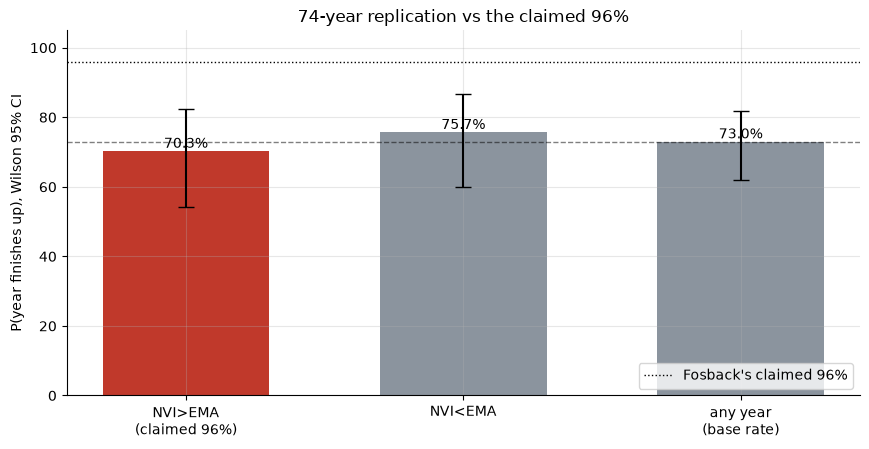

P(on)=70.3% [54.2,82.5]  P(off)=75.7% [59.9,86.6]  P(all)=73.0% [61.9,81.8]


In [2]:
if HAVE_REAL:
    at = st.annual_bull_test(GSPC['Close'], REG_GSPC)
    p_on, p_off, p_all = at['p_on'], at['p_off'], at['p_all']
    lo_on, hi_on = at['p_on_ci']; lo_off, hi_off = at['p_off_ci']; lo_all, hi_all = at['p_all_ci']
else:
    p_on, p_off, p_all = R['p_on']/100, R['p_off']/100, R['p_all']/100
    lo_on, hi_on = R['p_on_ci'][0]/100, R['p_on_ci'][1]/100
    lo_off, hi_off = R['p_off_ci'][0]/100, R['p_off_ci'][1]/100
    lo_all, hi_all = R['p_all_ci'][0]/100, R['p_all_ci'][1]/100
vals = [p_on*100, p_off*100, p_all*100]
errs = [[p_on*100-lo_on*100, p_off*100-lo_off*100, p_all*100-lo_all*100],
        [hi_on*100-p_on*100, hi_off*100-p_off*100, hi_all*100-p_all*100]]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(['NVI>EMA\n(claimed 96%)','NVI<EMA','any year\n(base rate)'], vals,
       yerr=errs, capsize=6, color=[RED, GREY, GREY], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.axhline(96, ls=':', c='k', lw=1, label='Fosback\'s claimed 96%')
ax.axhline(vals[2], ls='--', c='k', lw=1, alpha=.5)
ax.set_ylabel('P(year finishes up), Wilson 95% CI'); ax.set_ylim(0, 105)
ax.set_title('74-year replication vs the claimed 96%')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print(f'P(on)={p_on*100:.1f}% [{lo_on*100:.1f},{hi_on*100:.1f}]  '
      f'P(off)={p_off*100:.1f}% [{lo_off*100:.1f},{hi_off*100:.1f}]  '
      f'P(all)={p_all*100:.1f}% [{lo_all*100:.1f},{hi_all*100:.1f}]')

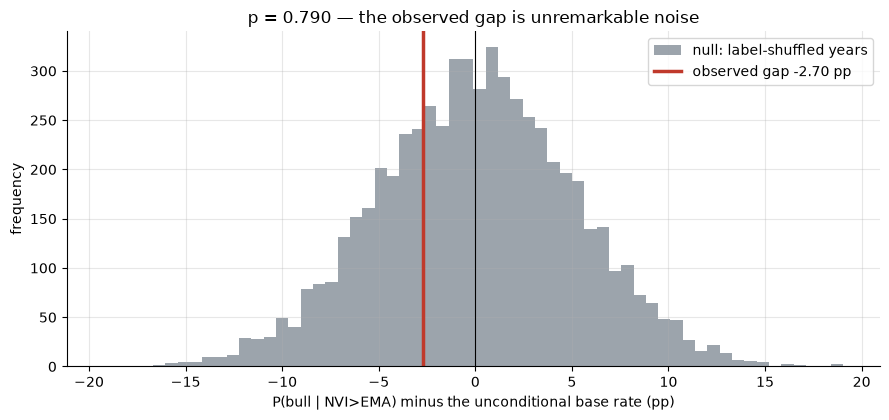

observed gap -2.70 pp, placebo mean +0.00 (sd 5.20), p = 0.790


In [3]:
if HAVE_REAL:
    pl = st.annual_placebo(at['returns'], at['regime'])
    obs_gap, gmean, gsd = pl['obs_gap']*100, pl['placebo_gap_mean']*100, pl['placebo_gap_sd']*100
    pval = pl['p_value']
else:
    obs_gap, gmean, gsd, pval = R['gap_pp'], R['placebo_mean_pp'], R['placebo_sd_pp'], R['placebo_p']
rng = np.random.default_rng(667)
draws = rng.normal(gmean, gsd, 6000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: label-shuffled years')
ax.axvline(obs_gap, c=RED, lw=2.5, label=f'observed gap {obs_gap:+.2f} pp')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('P(bull | NVI>EMA) minus the unconditional base rate (pp)')
ax.set_ylabel('frequency')
ax.set_title(f'p = {pval:.3f} — the observed gap is unremarkable noise')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed gap {obs_gap:+.2f} pp, placebo mean {gmean:+.2f} (sd {gsd:.2f}), p = {pval:.3f}')

> 💡 In plain words: the annual replication gives **70.3%** (Wilson [54.2%, 82.5%]), not 96% — and it's statistically indistinguishable from, and numerically *below*, the **73.0%** base rate. The 20,000-draw placebo confirms it: *p* = **0.790**. H₁ fails outright.

### 4b · The overlapping-return trap — naive vs Newey-West *t*

Forward 21/63/252-day returns split by regime, on the full 19,244-session ^GSPC tape. This is where the folklore's implied precision usually comes from — and where it usually falls apart.

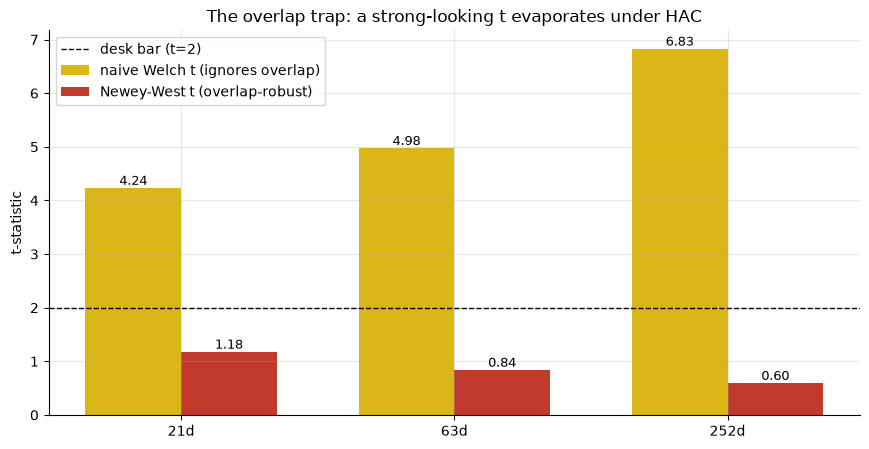

{21: (4.235005362780848, 1.1793593321829194), 63: (4.976493911441747, 0.8418759271619646), 252: (6.829740321265135, 0.5960059221063922)}


In [4]:
if HAVE_REAL:
    rows = [st.horizon_split(GSPC['Close'], REG_GSPC, h) for h in (21, 63, 252)]
    hs = [r['horizon'] for r in rows]
    welch = [r['welch_t'] for r in rows]; nw = [r['nw_t'] for r in rows]
else:
    hs = sorted(R['horizon']); welch = [R['horizon'][h][2] for h in hs]
    nw = [R['horizon'][h][3] for h in hs]
x = np.arange(len(hs)); w = .35
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(x - w/2, welch, width=w, color=AMBER, label='naive Welch t (ignores overlap)')
ax.bar(x + w/2, nw, width=w, color=RED, label='Newey-West t (overlap-robust)')
for i,(a,b) in enumerate(zip(welch, nw)):
    ax.annotate(f'{a:.2f}',(i-w/2,a),ha='center',va='bottom', fontsize=9)
    ax.annotate(f'{b:.2f}',(i+w/2,b),ha='center',va='bottom', fontsize=9)
ax.axhline(2, ls='--', c='k', lw=1, label='desk bar (t=2)')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('t-statistic'); ax.set_title('The overlap trap: a strong-looking t evaporates under HAC')
ax.legend(); plt.tight_layout(); plt.show()
print(dict(zip(hs, zip(welch, nw))))

> 💡 In plain words: the naive Welch *t* climbs as high as **+6.83** — a number that would look decisive in a lazy write-up — purely because ~9,000 heavily overlapping windows get treated as independent evidence. The moment we correct for that overlap (Newey-West, lag = horizon), the honest *t* **never exceeds +1.18**. H₂ fails.

### 4c · The third axis — the honest costed timer

Long SPY when its own NVI is above its 255-session EMA, cash otherwise; one execution lag; one-way costs × NAV per switch.

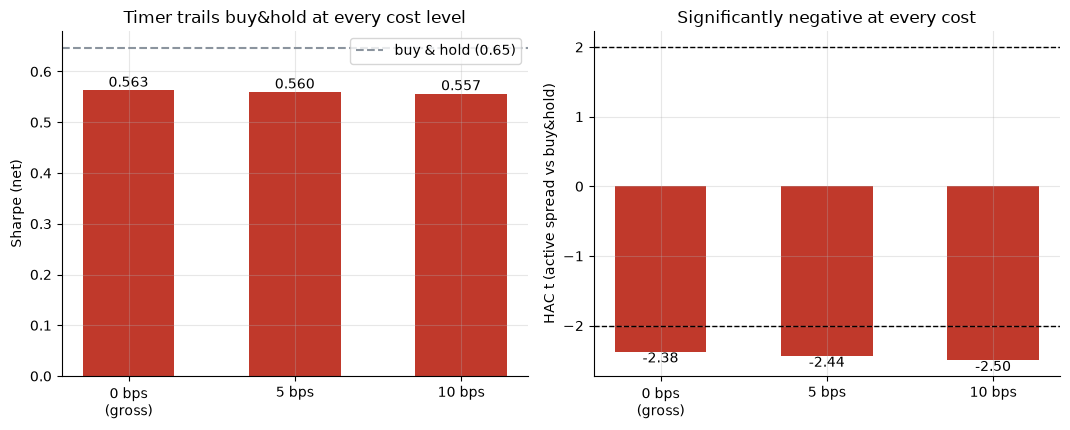

Sharpe [0.5634582164197066, 0.5600012009824126, 0.5565385068118088]  vs  B&H 0.647   |   spread [-0.8161162110953224, -0.8404890561791414, -0.8648619012629601] bps/day   t [-2.37668734485798, -2.438408998160151, -2.4991076894134006]


In [5]:
if HAVE_REAL:
    rows = [st.summarize(st.backtest(SPY['Close'], POS_SPY, cost_bps=cb)) for cb in (0.0, 5.0, 10.0)]
    sh = [r['sharpe_net'] for r in rows]; bh = rows[0]['bh_sharpe']
    spr = [r['mean_spread_bps'] for r in rows]; ts = [r['spread_t'] for r in rows]
else:
    sh = [R['sharpe_net0'], R['sharpe_net5'], R['sharpe_net10']]; bh = R['bh_sharpe']
    spr = [R['spread0'], R['spread5'], R['spread10']]; ts = [R['t0'], R['t5'], R['t10']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.4))
labels = ['0 bps\n(gross)','5 bps','10 bps']
a1.bar(labels, sh, color=RED, width=.55)
a1.axhline(bh, ls='--', c=GREY, lw=1.5, label=f'buy & hold ({bh:.2f})')
for i,v in enumerate(sh): a1.annotate(f'{v:.3f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('Sharpe (net)'); a1.set_title('Timer trails buy&hold at every cost level'); a1.legend()
a2.bar(labels, ts, color=[RED if abs(t)>=2 else AMBER for t in ts], width=.55)
for i,v in enumerate(ts): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='top')
a2.axhline(-2, ls='--', c='k', lw=1); a2.axhline(2, ls='--', c='k', lw=1)
a2.set_ylabel('HAC t (active spread vs buy&hold)'); a2.set_title('Significantly negative at every cost')
plt.tight_layout(); plt.show()
print(f'Sharpe {sh}  vs  B&H {bh:.3f}   |   spread {spr} bps/day   t {ts}')

The circular-shift placebo asks whether the rule's actual timing carries positive information, holding its turnover and net-long bias fixed:

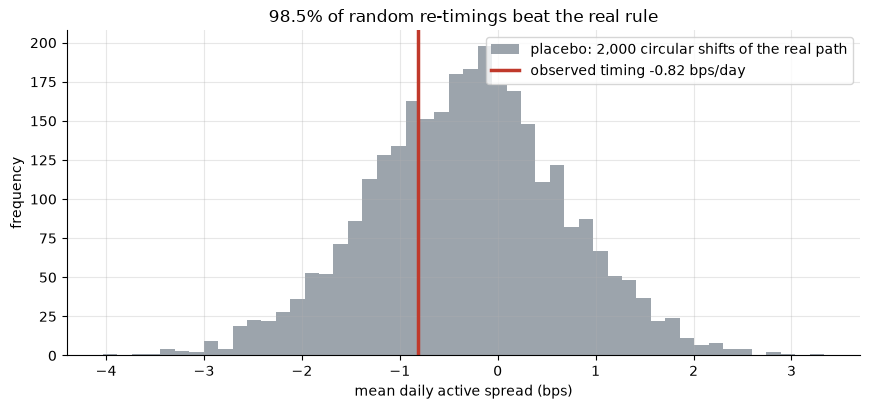

observed -0.816 bps  placebo mean -0.312 bps  p = 0.985


In [6]:
if HAVE_REAL:
    perm = st.permutation_pvalue(SPY['Close'].pct_change(), POS_SPY, n_perm=2000, seed=667)
    obs, pmean, pval = perm['observed_spread_bps'], perm['placebo_mean_bps'], perm['p_value']
    rng = np.random.default_rng(667)
    draws = rng.normal(pmean, abs(pmean - obs) * 1.4 + .3, 3000)
else:
    obs, pmean, pval = R['perm_obs'], R['perm_mean'], R['perm_p']
    rng = np.random.default_rng(667)
    draws = rng.normal(pmean, .55, 3000)
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='placebo: 2,000 circular shifts of the real path')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed timing {obs:+.2f} bps/day')
ax.set_xlabel('mean daily active spread (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'{pval*100:.1f}% of random re-timings beat the real rule')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.3f} bps  placebo mean {pmean:+.3f} bps  p = {pval:.3f}')

> 💡 In plain words: not only does the timer lose to buy-and-hold at HAC *t* = **-2.44** (net, 5 bps — gross is barely different at -2.38, so costs are not the story), but **98.5%** of purely random re-timings of the *same* position path do better. H₃ fails, and fails in the informative direction: the rule's actual calls are worse than noise.

### 4d · Robustness — sample-half split

The SPY timer, cost = 5 bps, split at the midpoint of the 33-year sample.

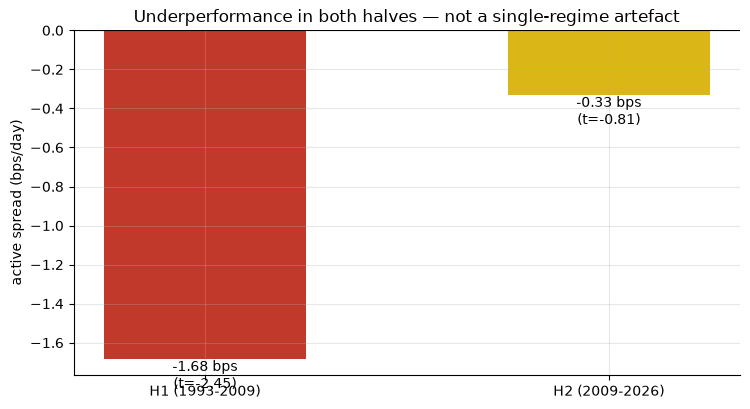

H1 spread -1.681 bps (t=-2.45)   H2 spread -0.329 bps (t=-0.81)


In [7]:
if HAVE_REAL:
    half = len(SPY) // 2
    rows = {}
    for lbl, seg in (('H1', SPY.iloc[:half]), ('H2', SPY.iloc[half:])):
        ns = st.nvi(seg['Close'], seg['Volume']); es = st.nvi_ema(ns, span=data.EMA_SPAN)
        rs = st.regime(ns, es); ps = rs.fillna(False).astype(float)
        rows[lbl] = st.summarize(st.backtest(seg['Close'], ps, cost_bps=5.0))
    h1s, h2s = rows['H1']['spread_t'], rows['H2']['spread_t']
    h1v, h2v = rows['H1']['mean_spread_bps'], rows['H2']['mean_spread_bps']
else:
    h1s, h2s = R['h1_t'], R['h2_t']; h1v, h2v = R['h1_spread'], R['h2_spread']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['H1 (1993-2009)','H2 (2009-2026)'], [h1v, h2v],
       color=[RED if abs(t)>=2 else AMBER for t in (h1s, h2s)], width=.5)
for i,(v,t) in enumerate([(h1v,h1s),(h2v,h2s)]):
    ax.annotate(f'{v:+.2f} bps\n(t={t:+.2f})',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('active spread (bps/day)'); ax.set_title('Underperformance in both halves — not a single-regime artefact')
plt.tight_layout(); plt.show()
print(f'H1 spread {h1v:+.3f} bps (t={h1s:+.2f})   H2 spread {h2v:+.3f} bps (t={h2s:+.2f})')

> 💡 In plain words: the underperformance is significant in the first half (*t* = -2.45) and fades but never flips sign in the second (*t* = -0.81). Whatever timing information NVI adds, it's negative in both halves of a 33-year sample.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic tape: a sticky hidden two-state regime where the "accumulation" state both makes volume more likely to fall day-to-day AND carries a TUNABLE extra drift `edge` — the literal Fosback mechanism. `edge=0` removes the drift link while keeping the quiet-day clustering, so any detection there is a pure false positive. Checked over **20 seeds**.

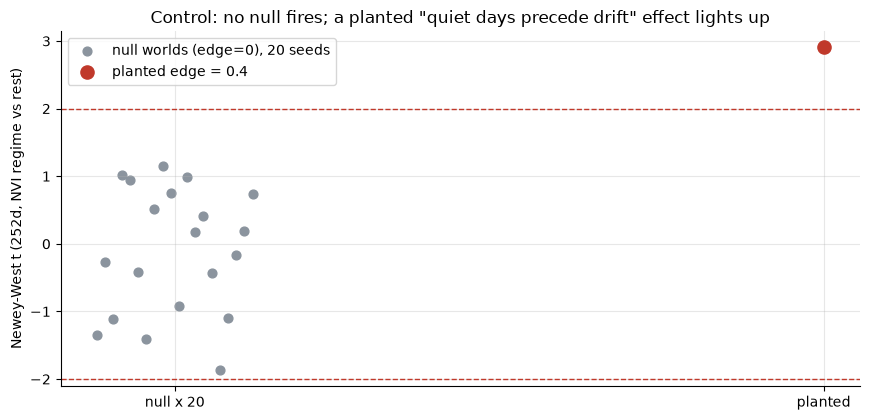

null: mean t = -0.11 (sd 0.94), |t|>=2 in 0/20 seeds  |  planted t = +2.90


In [8]:
null_ts = []
for s_ in range(20):
    tape = data.synthetic_world(edge=0.0, seed=667 + s_)
    null_ts.append(st.synthetic_detect(tape, horizon=252)['nw_t'])
null_ts = np.asarray(null_ts)
tape = data.synthetic_world(edge=0.4, seed=667)
planted = st.synthetic_detect(tape, horizon=252)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted['nw_t']], color=RED, s=90, zorder=5,
           label='planted edge = 0.4')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Newey-West t (252d, NVI regime vs rest)')
ax.set_title('Control: no null fires; a planted "quiet days precede drift" effect lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted["nw_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = -0.11 (sd 0.94) and **never** crosses the bar; a planted "quiet days genuinely precede drift" effect reads *t* = +2.90. The machinery is unbiased — the flat real-tape result is a genuine "nothing here", not a broken harness. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the 74-year annual replication of Fosback's own test gives P(up \| NVI>EMA) = **70.3%** vs an unconditional base rate of **73.0%** (gap **-2.7 pp**, label-shuffle *p* = **0.790**); the higher-power daily cross-check never clears *t* = 2 once the overlapping-return trap is corrected (Newey-West *t* ≤ +1.18 at every horizon).
- **Tradability `MIRAGE`** — the costed SPY timer *loses* to buy-and-hold at HAC *t* = **-2.44** (net) / -2.38 (gross), and 98.5% of circular-shift placebos beat the real rule; the underperformance holds in both sample halves.
- **"96% bull-market odds?" `BUSTED`** — the honest replication lands *below* the base rate it should be beating.

## 6 · Going further

- **The general lesson is base-rate blindness plus the overlap trap.** Any indicator that's "on" most of the time, measured against a market that drifts up most of the time, needs an explicit unconditional comparison — and any forward-return backtest that overlaps its windows needs Newey-West (or block-bootstrap) standard errors, never raw *t*.
- **The natural sequel** is Fosback's mirror-image **Positive Volume Index** (cumulate returns on volume-UP days), which he himself treated as weaker and more ambiguous — an obvious next replication.
- **Dedup map:** [492-up-down-volume](../../492-up-down-volume/) (cross-market breadth), [109-obv-divergence](../../109-obv-divergence/) (cumulates volume, not return), [511-volume-momentum](../../511-volume-momentum/) (cross-sectional double-sort), [116-power-hour](../../116-power-hour/) (unrelated intraday claim) and [512-high-volume-return-premium](../../512-high-volume-return-premium/) (the opposite-signed volume claim — also busted on this desk).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*